In [1]:
import sklearn
from sklearn.datasets import make_circles


In [2]:
n_samples = 1000
x, y = make_circles(n_samples, noise= 0.03, random_state = 42)

In [19]:
type(x)

torch.Tensor

In [3]:
x[:5], y[:5]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]))

In [4]:
y


array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,

In [7]:
import pandas as pd
circles = pd.DataFrame({"X1" : x[:, 0],
                        "X2": x[:, 0],
                        "labels": y})
print(circles.head(10))

         X1        X2  labels
0  0.754246  0.754246       1
1 -0.756159 -0.756159       1
2 -0.815392 -0.815392       1
3 -0.393731 -0.393731       1
4  0.442208  0.442208       0
5 -0.479646 -0.479646       1
6 -0.013648 -0.013648       1
7  0.771513  0.771513       1
8 -0.169322 -0.169322       1
9 -0.121486 -0.121486       0


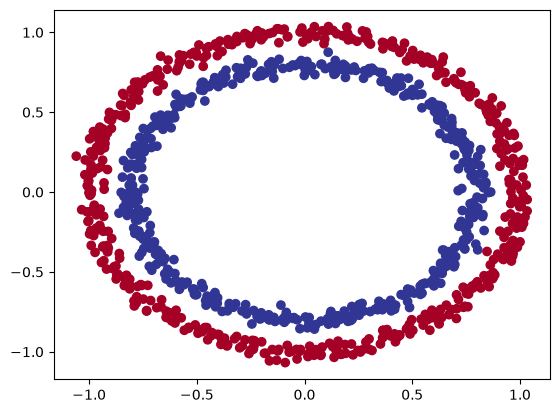

In [11]:
##visualize


import matplotlib.pyplot as plt

plt.scatter(x = x[:, 0],
            y = x[:, 1],
            c = y,
            label = "data",
            cmap = plt.cm.RdYlBu)

In [14]:
x_sample = x[0]
y_sample = y[0]

print(f"value for one smaple of {x_sample} and {y_sample}")


value for one smaple of [0.75424625 0.23148074] and 1


In [28]:
import torch as tr
from torch import nn
device = "cuda" if tr.cuda.is_available() else "cpu"
type(x), device

(torch.Tensor, 'cuda')

In [22]:
from sklearn.model_selection import train_test_split


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=42)
len(x_train), len(x_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [29]:
x_train.shape

torch.Size([800, 2])

In [53]:
## Building a Model and construct a model that subclasses nn.Module


class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features = 2, out_features= 5)
        self.layer_2 = nn.Linear(in_features = 5, out_features = 1)
           


    def forward(self, x):
        return self.layer_2(self.layer_1(x))


model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [54]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [55]:
model_0 = nn.Sequential(
    nn.Linear(in_features = 2, out_features=5),
    nn.Linear(in_features = 5, out_features= 1),
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [56]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.2857, -0.0834],
                      [ 0.6423, -0.0699],
                      [-0.0981,  0.6376],
                      [ 0.0039,  0.6933],
                      [ 0.4926,  0.1421]], device='cuda:0')),
             ('0.bias',
              tensor([ 0.6591,  0.1086, -0.0219,  0.2748,  0.5430], device='cuda:0')),
             ('1.weight',
              tensor([[ 0.4355, -0.4395,  0.1586,  0.3043,  0.3784]], device='cuda:0')),
             ('1.bias', tensor([-0.3931], device='cuda:0'))])

In [57]:
x_train = x_train.float().to(device)
y_train = y_train.float().to(device)
x_test = x_test.float().to(device)
y_test = y_test.float().to(device)


# x_train = tr.tensor(x_train, dtype=tr.float32).to(device)
# y_train = tr.tensor(y_train, dtype=tr.float32).to(device)
# x_test = tr.tensor(x_test, dtype=tr.float32).to(device)
# y_test = tr.tensor(y_test, dtype=tr.float32).to(device)

In [58]:
## Make Prediction
model_0.eval()
with tr.inference_mode():
    untrained_preds = model_0(x_test.to(device))
print(f"Length of predcition: {len(untrained_preds)}, shape: {untrained_preds.shape}")
print(f"length of test samples: {len(x_test)}, shape: {x_test.shape}")
print(f"nfirst 10 preds: {untrained_preds[: 10]}")


Length of predcition: 200, shape: torch.Size([200, 1])
length of test samples: 200, shape: torch.Size([200, 2])
nfirst 10 preds: tensor([[ 0.4658],
        [ 0.4740],
        [ 0.1834],
        [ 0.5469],
        [-0.2305],
        [-0.2223],
        [ 0.1291],
        [-0.0351],
        [ 0.2013],
        [ 0.4700]], device='cuda:0')


In [59]:
## setup loss and optimizer

loss_fn = nn.BCEWithLogitsLoss()
optimizer = tr.optim.SGD(params = model_0.parameters(),
                         lr = 0.01)
                         



In [61]:
##calculate accuracy 

def accuracy_fn(y_true, y_pred):
    correct = tr.eq(y_true, y_pred).sum().item()
    acc = (correct/ len(y_pred)) * 100
    return acc



<function __main__.accuracy_fn(y_true, y_pred)>

In [66]:
## Raw Logits to Predciton probabilities -> prediciton tables
model_0.eval()
with tr.inference_mode():
    y_logits = model_0(x_test.to(device))[:5]
y_logits


tensor([[ 0.4658],
        [ 0.4740],
        [ 0.1834],
        [ 0.5469],
        [-0.2305]], device='cuda:0')

In [69]:
## use sigmoid function 

y_pred_probs = tr.sigmoid(y_logits)
y_pred_probs

tensor([[0.6144],
        [0.6163],
        [0.5457],
        [0.6334],
        [0.4426]], device='cuda:0')

In [72]:
y_preds = tr.round(y_pred_probs)

y_pred_labels = tr.round(tr.sigmoid(model_0(x_test.to(device))[:5]))
print(tr.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

tensor([True, True, True, True, True], device='cuda:0')


In [77]:
# building and training a testing loop
tr.manual_seed(42)
tr.cuda.manual_seed(42)
epochs = 100

x_train, y_train = x_train.to(device), y_train.to(device)
x_test, y_test = x_test.to(device), y_test.to(device)

for epoch in range(epochs):
    model_0.train()

    y_logits = model_0(x_train).squeeze()
    y_pred = tr.round(tr.sigmoid(y_logits))

    ## sigmoid can also be used here
    loss = loss_fn(y_logits,
                   y_train)
    acc = accuracy_fn(y_true=y_train,
                      y_pred = y_pred)

    ##optimizer

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_0.eval()

    with tr.inference_mode():
        test_logits = model_0(x_test).squeeze()
        test_pred = tr.round(tr.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true= y_test, 
                               y_pred = test_pred)
    if epoch % 10 == 0:
        print(f"epoch : {epoch} | loss : {loss:.5f} | acc: {acc:.5f} | test loss: {test_loss:.5f} | test acc: {test_acc:.5f}")

epoch : 0 | loss : 0.69975 | acc: 51.12500 | test loss: 0.70515 | test acc: 50.00000
epoch : 10 | loss : 0.69951 | acc: 51.12500 | test loss: 0.70483 | test acc: 50.50000
epoch : 20 | loss : 0.69928 | acc: 50.75000 | test loss: 0.70452 | test acc: 51.00000
epoch : 30 | loss : 0.69907 | acc: 50.62500 | test loss: 0.70423 | test acc: 51.00000
epoch : 40 | loss : 0.69886 | acc: 50.75000 | test loss: 0.70395 | test acc: 50.00000
epoch : 50 | loss : 0.69867 | acc: 50.75000 | test loss: 0.70368 | test acc: 49.50000
epoch : 60 | loss : 0.69848 | acc: 50.87500 | test loss: 0.70343 | test acc: 49.50000
epoch : 70 | loss : 0.69830 | acc: 51.12500 | test loss: 0.70318 | test acc: 49.50000
epoch : 80 | loss : 0.69814 | acc: 51.25000 | test loss: 0.70295 | test acc: 49.50000
epoch : 90 | loss : 0.69798 | acc: 51.00000 | test loss: 0.70273 | test acc: 49.00000


In [82]:
## prediction with this model 

import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
    print("helper_functions.py already exists")
else:
    print("download helper function")
    requests = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
    with open("helper_functions.py", "wb") as f:
        f.write(requests.content)

from helper_functions import plot_predictions, plot_decision_boundary


helper_functions.py already exists


Text(0.5, 1.0, 'Test')

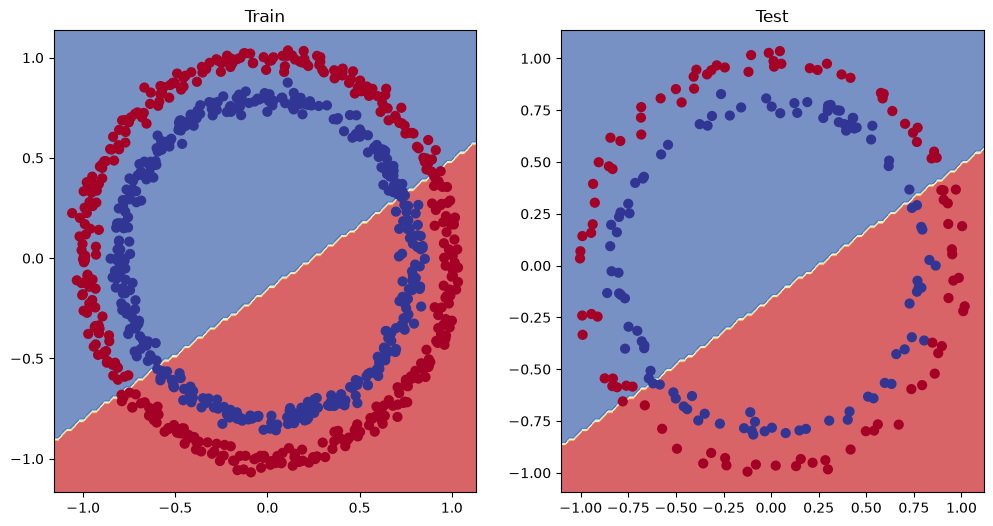

In [83]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, x_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, x_test, y_test)
plt.title("Test")

In [84]:
## improving model 
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features = 2, out_features= 10)
        self.layer_2 = nn.Linear(in_features = 10, out_features= 10)
        self.layer_3 = nn.Linear(in_features = 10, out_features= 1)

    def forward(self, x):
        return self.layer_3(self.layer_2(self.layer_1(x)))


model_1 = CircleModelV1().to(device)
model_1



CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [85]:

# building and training a testing loop
tr.manual_seed(42)
tr.cuda.manual_seed(42)
epochs = 100

x_train, y_train = x_train.to(device), y_train.to(device)
x_test, y_test = x_test.to(device), y_test.to(device)

for epoch in range(epochs):
    model_1.train()

    y_logits = model_1(x_train).squeeze()
    y_pred = tr.round(tr.sigmoid(y_logits))

    ## sigmoid can also be used here
    loss = loss_fn(y_logits,
                   y_train)
    acc = accuracy_fn(y_true=y_train,
                      y_pred = y_pred)

    ##optimizer

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_1.eval()

    with tr.inference_mode():
        test_logits = model_1(x_test).squeeze()
        test_pred = tr.round(tr.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true= y_test, 
                               y_pred = test_pred)
    if epoch % 10 == 0:
        print(f"epoch : {epoch} | loss : {loss:.5f} | acc: {acc:.5f} | test loss: {test_loss:.5f} | test acc: {test_acc:.5f}")

epoch : 0 | loss : 0.69396 | acc: 50.87500 | test loss: 0.69261 | test acc: 51.00000
epoch : 10 | loss : 0.69396 | acc: 50.87500 | test loss: 0.69261 | test acc: 51.00000
epoch : 20 | loss : 0.69396 | acc: 50.87500 | test loss: 0.69261 | test acc: 51.00000
epoch : 30 | loss : 0.69396 | acc: 50.87500 | test loss: 0.69261 | test acc: 51.00000
epoch : 40 | loss : 0.69396 | acc: 50.87500 | test loss: 0.69261 | test acc: 51.00000
epoch : 50 | loss : 0.69396 | acc: 50.87500 | test loss: 0.69261 | test acc: 51.00000
epoch : 60 | loss : 0.69396 | acc: 50.87500 | test loss: 0.69261 | test acc: 51.00000
epoch : 70 | loss : 0.69396 | acc: 50.87500 | test loss: 0.69261 | test acc: 51.00000
epoch : 80 | loss : 0.69396 | acc: 50.87500 | test loss: 0.69261 | test acc: 51.00000
epoch : 90 | loss : 0.69396 | acc: 50.87500 | test loss: 0.69261 | test acc: 51.00000


Text(0.5, 1.0, 'Test')

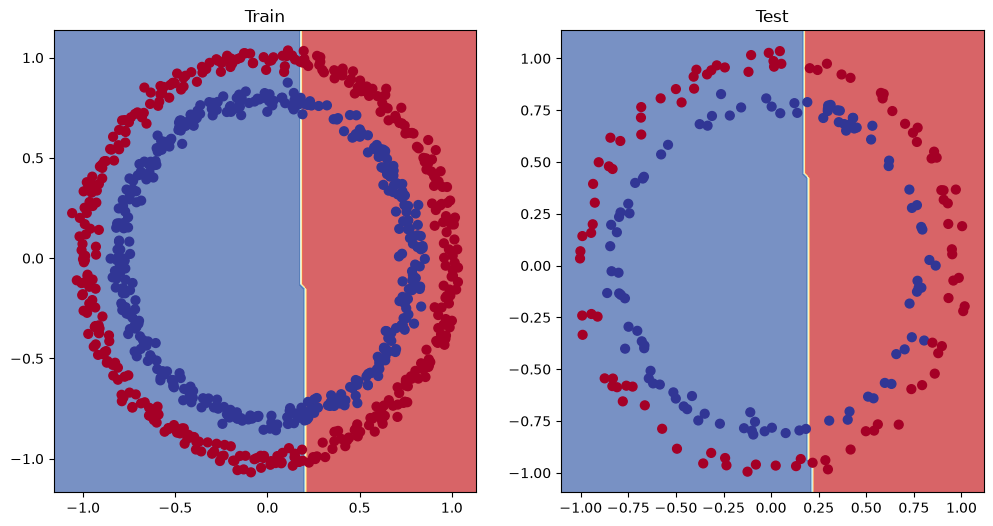

In [86]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, x_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, x_test, y_test)
plt.title("Test")

In [88]:
weight =0.7
bias = 0.3
start = 0
end = 1
step = 0.01

# Create data
X_regression = tr.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias

print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [91]:
ftrain_split = int(0.8 * len(X_regression))
x_train_regression, y_train_regression = X_regression[:ftrain_split], y_regression[:ftrain_split]
x_test_regression, y_test_regression = X_regression[ftrain_split:], y_regression[ftrain_split:]

len(x_train_regression), len(y_train_regression), len(x_test_regression), len(y_test_regression)

(80, 80, 20, 20)

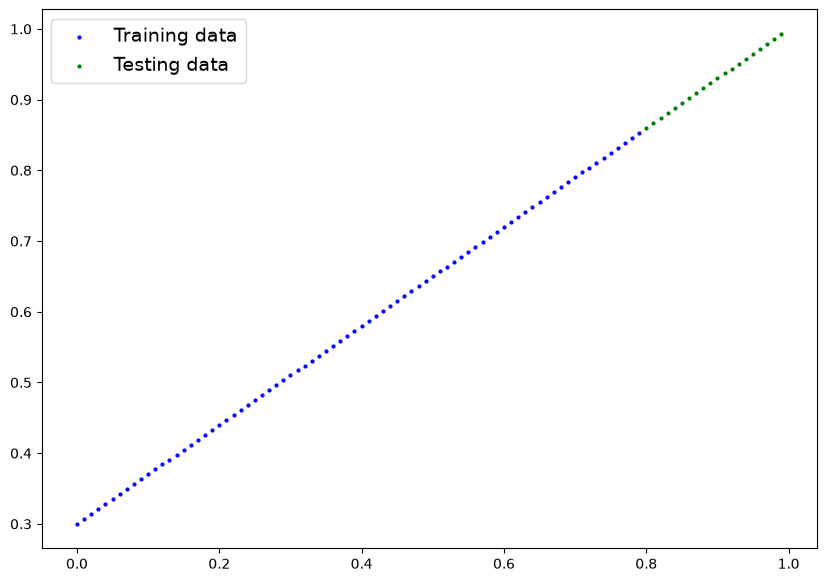

In [97]:
plot_predictions(train_data = x_train_regression, train_labels = y_train_regression, test_data = x_test_regression, test_labels = y_test_regression, )

In [101]:
model_2 = nn.Sequential(
    nn.Linear(in_features = 1, out_features= 10),
    nn.Linear(in_features = 10, out_features= 10),
    nn.Linear(in_features = 10, out_features= 1)
).to(device)
model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [102]:
loss_fn = nn.L1Loss()
optimizer = tr.optim.SGD(params = model_2.parameters(),
                         lr = 0.01)

In [106]:
tr.manual_seed(42)
if tr.cuda.is_available():
    tr.cuda.manual_seed(42)

epochs = 100

model_2 = model_2.to(device)

x_train_regression = x_train_regression.to(device).float()
y_train_regression = y_train_regression.to(device).float()
x_test_regression = x_test_regression.to(device).float()
y_test_regression = y_test_regression.to(device).float()

optimizer = tr.optim.SGD(model_2.parameters(), lr=0.01)

for epoch in range(epochs):
    model_2.train()

    y_pred = model_2(x_train_regression)

    # Prediction first, actual labels second
    loss = loss_fn(y_pred, y_train_regression)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_2.eval()
    with tr.inference_mode():
        test_pred = model_2(x_test_regression)
        test_loss = loss_fn(test_pred, y_test_regression)

    if epoch % 10 == 0:
        print(f"epoch: {epoch} | loss: {loss:.5f} | test loss: {test_loss:.5f}")

epoch: 0 | loss: 0.75986 | test loss: 0.91103
epoch: 10 | loss: 0.40240 | test loss: 0.50474
epoch: 20 | loss: 0.06007 | test loss: 0.10151
epoch: 30 | loss: 0.01559 | test loss: 0.03231
epoch: 40 | loss: 0.03092 | test loss: 0.00111
epoch: 50 | loss: 0.03196 | test loss: 0.00108
epoch: 60 | loss: 0.03192 | test loss: 0.00170
epoch: 70 | loss: 0.03081 | test loss: 0.00097
epoch: 80 | loss: 0.03077 | test loss: 0.00150
epoch: 90 | loss: 0.02967 | test loss: 0.00092


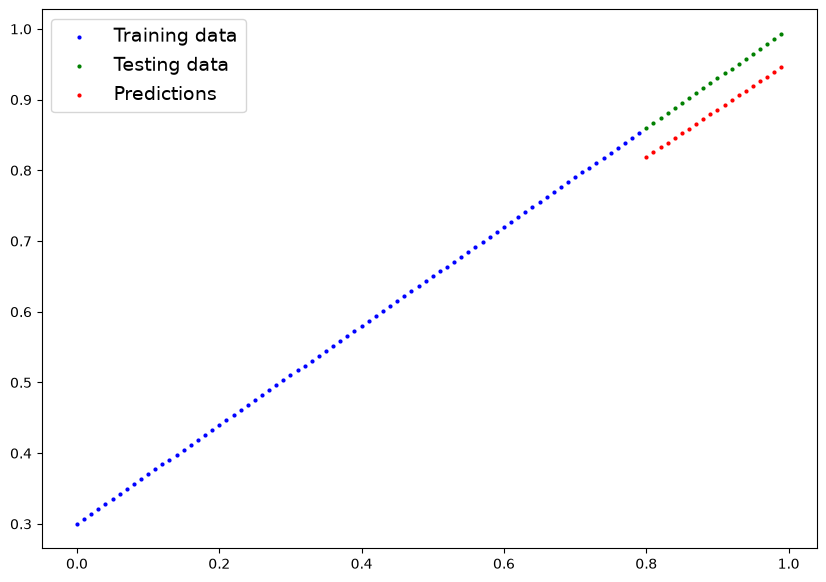

In [109]:
plot_predictions(
    train_data = x_train_regression.cpu().numpy(),
    train_labels = y_train_regression.cpu().numpy(),
    test_data = x_test_regression.cpu().numpy(),
    test_labels = y_test_regression.cpu().numpy(),
    predictions = test_pred.cpu().numpy()

)

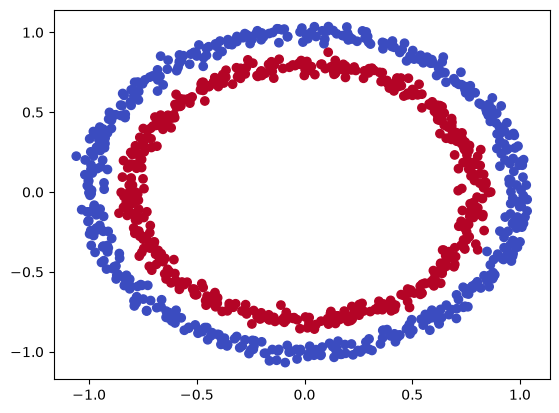

In [110]:
n_samples = 1000
x, y = make_circles(n_samples, noise= 0.03, random_state = 42)

plt.scatter(x = x[:, 0],
            y = x[:, 1],
            c = y, cmap = 'coolwarm')

In [111]:
x = tr.from_numpy(x).type(tr.float32)
y = tr.from_numpy(y).type(tr.float32)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=42)
x_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

In [112]:
# Building a model in non linearity
# build a model with non linear function 

class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features = 2, out_features= 10)
        self.layer_2 = nn.Linear(in_features = 10, out_features= 10)
        self.layer_3 = nn.Linear(in_features = 10, out_features= 1)
        self.relu = nn.ReLU()  #ReLU is a non lienar activation functions

    def forward(self, x):
        x = self.relu(self.layer_1(x))
        x = self.relu(self.layer_2(x))
        x = self.layer_3(x)
        return x

model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [119]:
## setup loss and optimizer

loss_fn = nn.BCEWithLogitsLoss()
optimizer = tr.optim.SGD(model_3.parameters(), lr=0.01)




In [121]:

# building and training a testing loop
tr.manual_seed(42)
tr.cuda.manual_seed(42)
epochs = 100

x_train, y_train = x_train.to(device), y_train.to(device)
x_test, y_test = x_test.to(device), y_test.to(device)

for epoch in range(epochs):
    model_3.train()

    y_logits = model_3(x_train).squeeze()
    y_pred = tr.round(tr.sigmoid(y_logits))

    ## sigmoid can also be used here
    loss = loss_fn(y_logits,
                   y_train)
    acc = accuracy_fn(y_true=y_train,
                      y_pred = y_pred)

    ##optimizer

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_3.eval()

    with tr.inference_mode():
        test_logits = model_3(x_test).squeeze()
        test_pred = tr.round(tr.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true= y_test, 
                               y_pred = test_pred)
    if epoch % 10 == 0:
        print(f"epoch : {epoch} | loss : {loss:.5f} | acc: {acc:.5f} | test loss: {test_loss:.5f} | test acc: {test_acc:.5f}")

epoch : 0 | loss : 0.69103 | acc: 52.87500 | test loss: 0.69089 | test acc: 53.00000
epoch : 10 | loss : 0.69101 | acc: 52.87500 | test loss: 0.69088 | test acc: 53.50000
epoch : 20 | loss : 0.69100 | acc: 52.87500 | test loss: 0.69087 | test acc: 53.50000
epoch : 30 | loss : 0.69099 | acc: 52.87500 | test loss: 0.69085 | test acc: 53.50000
epoch : 40 | loss : 0.69098 | acc: 52.87500 | test loss: 0.69084 | test acc: 54.00000
epoch : 50 | loss : 0.69096 | acc: 52.75000 | test loss: 0.69082 | test acc: 54.00000
epoch : 60 | loss : 0.69095 | acc: 52.75000 | test loss: 0.69081 | test acc: 54.00000
epoch : 70 | loss : 0.69094 | acc: 52.75000 | test loss: 0.69079 | test acc: 54.00000
epoch : 80 | loss : 0.69092 | acc: 53.00000 | test loss: 0.69078 | test acc: 54.00000
epoch : 90 | loss : 0.69091 | acc: 53.12500 | test loss: 0.69076 | test acc: 54.00000


In [125]:
## replication non linear functions 

a = tr.arange(-10, 10, 1, dtype=tr.float32)
a.dtype


torch.float32

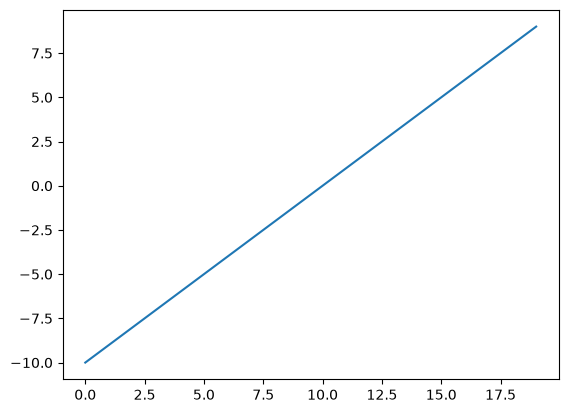

In [126]:
plt.plot(a)

In [128]:


def relu(x: tr.Tensor) -> tr.Tensor:
    return tr.maximum(tr.tensor(0), x)

relu(a)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

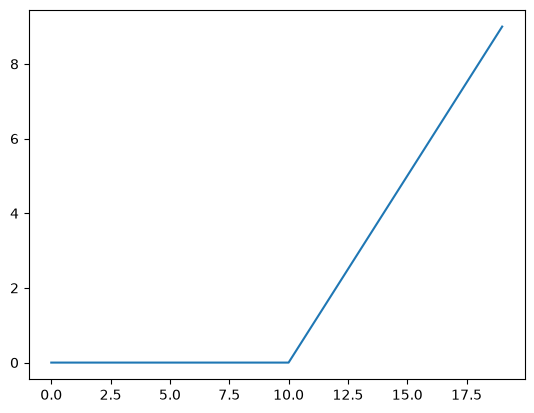

In [129]:
plt.plot(relu(a))

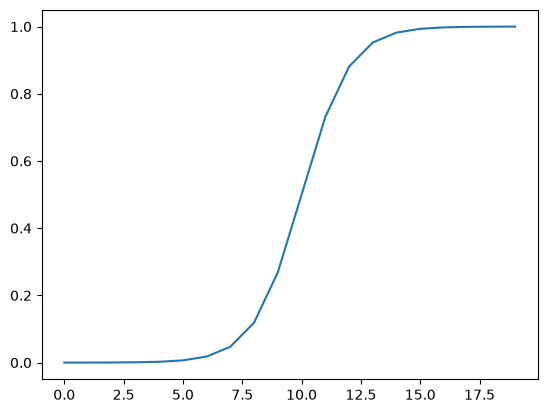

In [131]:
def sigmoid(x: tr.Tensor) -> tr.Tensor:
    return 1 / ( 1 + tr.exp(-x))

sigmoid(a)

plt.plot(sigmoid(a))

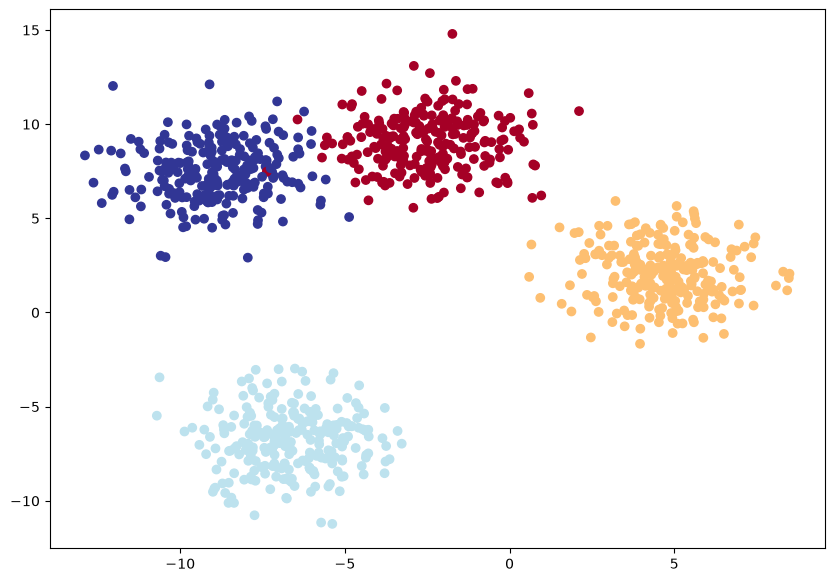

In [132]:
## putting it all together with multi class classification
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split


num_classes = 4
num_features = 2
random_seed = 42


x_blob, y_blob = make_blobs(n_samples=1000, n_features = num_features, centers = num_classes, cluster_std = 1.5, random_state = random_seed)

x_blob = tr.from_numpy(x_blob).type(tr.float32)
y_blob = tr.from_numpy(y_blob).type(tr.float)

x_blob_train, x_blob_test, y_blob_train, y_blob_test = train_test_split(x_blob, y_blob, test_size = 0.2, random_state = random_seed)

plt.figure(figsize=(10, 7))
plt.scatter(x_blob[:, 0], x_blob[:, 1], c = y_blob, cmap = plt.cm.RdYlBu)


In [144]:
## building a multi class classificaiton model
device = "cuda" if tr.cuda.is_available() else "cpu"

class blobmodel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units = 8):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features = input_features, out_features = hidden_units),
            nn.Linear(in_features = hidden_units, out_features = hidden_units),
            nn.Linear(in_features = hidden_units, out_features = output_features)
            
        )

    def forward(self, x):
        return self.linear_layer_stack(x)



model_4 = blobmodel(input_features = 2, output_features = 4, hidden_units = 8).to(device)

model_4



blobmodel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [145]:
tr.unique(y_blob_train, return_counts = True)

(tensor([0., 1., 2., 3.]), tensor([201, 209, 197, 193]))

In [146]:
loss_fn = nn.CrossEntropyLoss()
optimizer = tr.optim.SGD(params = model_4.parameters(), lr = 0.01)


In [147]:
model_4.eval()
with tr.inference_mode():
    y_preds = model_4(x_blob_test.to(device))


y_preds[:5]

tensor([[ 1.1940,  0.2118, -0.7930,  1.0172],
        [ 0.0936, -4.1314,  1.7660,  1.4851],
        [-1.3870, -0.3346,  1.8118, -1.5638],
        [ 0.7131,  0.6526, -0.4988,  0.3292],
        [ 1.3155, -2.4986,  0.0485,  2.1827]], device='cuda:0')

In [154]:
print(y_logits.shape)
print(model_4)

torch.Size([800])
blobmodel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)


In [158]:
model_4.eval()

with tr.inference_mode():
    y_logits = model_4(x_blob_test.to(device))

print(y_logits.shape)  # expected: torch.Size([200, 4])

y_preds_prob = tr.softmax(y_logits, dim=1)
y_preds = tr.argmax(y_preds_prob, dim=1)

print(y_preds[:5])

torch.Size([200, 4])
tensor([0, 2, 2, 0, 3], device='cuda:0')


In [159]:
tr.sum(y_preds_prob[0])

tensor(1., device='cuda:0')

In [161]:
tr.max(y_preds_prob[0])

tensor(0.4256, device='cuda:0')

In [162]:
##predictioni probabilities to prediction labels

y_preds = tr.argmax(y_preds_prob, dim=1)
y_preds

tensor([0, 2, 2, 0, 3, 2, 2, 3, 2, 3, 3, 0, 3, 3, 3, 2, 2, 2, 3, 2, 3, 3, 0, 2,
        2, 2, 2, 3, 0, 3, 2, 0, 0, 2, 0, 2, 1, 2, 3, 2, 3, 2, 2, 2, 3, 3, 0, 3,
        3, 3, 1, 3, 0, 1, 2, 2, 0, 1, 2, 2, 2, 3, 2, 2, 2, 3, 3, 3, 2, 3, 3, 3,
        2, 3, 2, 2, 2, 3, 3, 1, 3, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2,
        1, 3, 2, 2, 3, 3, 3, 3, 2, 2, 1, 3, 3, 2, 1, 1, 3, 2, 2, 2, 3, 3, 1, 2,
        2, 2, 3, 0, 2, 3, 3, 3, 2, 2, 0, 2, 3, 2, 3, 3, 3, 3, 0, 0, 0, 3, 2, 2,
        2, 2, 3, 2, 3, 2, 2, 0, 2, 2, 3, 3, 3, 2, 2, 0, 2, 3, 2, 2, 3, 2, 2, 3,
        2, 2, 2, 3, 3, 0, 0, 0, 1, 0, 2, 0, 3, 2, 2, 0, 2, 2, 3, 0, 2, 2, 3, 3,
        1, 2, 2, 3, 2, 0, 2, 0], device='cuda:0')

In [165]:
tr.manual_seed(42)
tr.cuda.manual_seed(42)

epochs = 100
x_blob_train, y_blob_train = x_blob_train.to(device).float(), y_blob_train.to(device).long()
x_blob_test, y_blob_test = x_blob_test.to(device).float(), y_blob_test.to(device).long()

for epoch in range(epochs):
    model_4.train()
    y_logits = model_4(x_blob_train)
    y_pred = tr.softmax(y_logits, dim= 1).argmax(dim= 1)
    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(y_true = y_blob_train, y_pred = y_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


    model_4.eval()

    with tr.inference_mode():
        test_logits = model_4(x_blob_test)
        test_pred = tr.softmax(test_logits, dim = 1).argmax(dim= 1)

        test_loss = loss_fn(test_logits, y_blob_test)
        test_acc = accuracy_fn(y_true = y_blob_test, y_pred = test_pred)

    if epoch % 10 == 0:
        print(f"epoch: {epoch} | loss: {loss:.5f} | acc: {acc:.5f} | test loss: {test_loss:.5f} | test acc: {test_acc:.5f}")


epoch: 0 | loss: 0.98100 | acc: 40.87500 | test loss: 0.78682 | test acc: 57.00000
epoch: 10 | loss: 0.43310 | acc: 94.00000 | test loss: 0.41067 | test acc: 96.50000
epoch: 20 | loss: 0.31859 | acc: 97.00000 | test loss: 0.30861 | test acc: 98.00000
epoch: 30 | loss: 0.25710 | acc: 98.00000 | test loss: 0.25156 | test acc: 99.00000
epoch: 40 | loss: 0.21730 | acc: 98.50000 | test loss: 0.21368 | test acc: 99.00000
epoch: 50 | loss: 0.18893 | acc: 98.75000 | test loss: 0.18615 | test acc: 99.00000
epoch: 60 | loss: 0.16757 | acc: 98.75000 | test loss: 0.16511 | test acc: 99.00000
epoch: 70 | loss: 0.15087 | acc: 98.87500 | test loss: 0.14846 | test acc: 99.00000
epoch: 80 | loss: 0.13747 | acc: 99.00000 | test loss: 0.13497 | test acc: 99.00000
epoch: 90 | loss: 0.12648 | acc: 99.00000 | test loss: 0.12381 | test acc: 99.00000


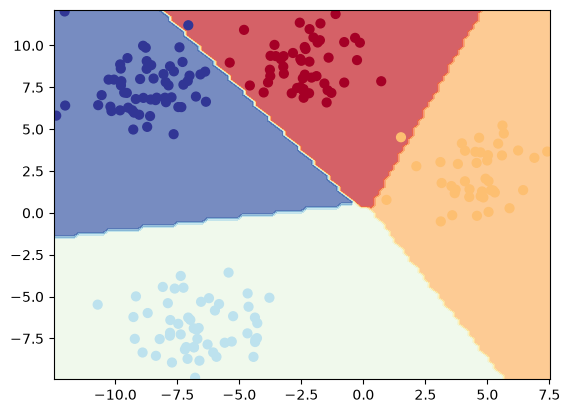

In [168]:
plot_decision_boundary(model_4, x_blob_test.cpu(), y_blob_test.cpu())

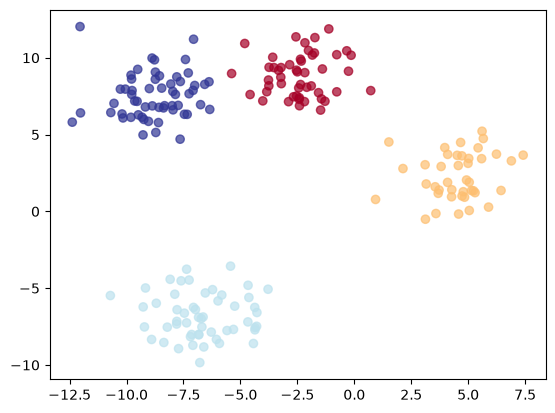

In [169]:
plt.scatter(x_blob_test.cpu()[:, 0], x_blob_test.cpu()[:, 1], c = y_blob_test.cpu(), cmap = plt.cm.RdYlBu, alpha = 0.7)

In [170]:
y_blob_test

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 3, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1], device='cuda:0')

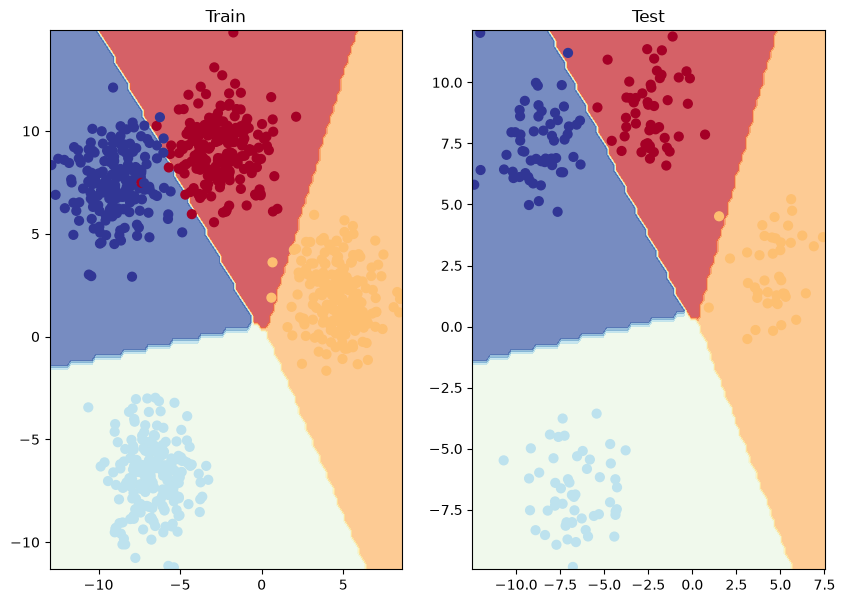

In [173]:
plt.figure(figsize={10, 7})
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_4, x_blob_train.cpu(), y_blob_train.cpu())
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_4, x_blob_test.cpu(), y_blob_test.cpu())


In [178]:
##few more classification mretrics
from torchmetrics import Accuracy

torchmetric_accuracy = Accuracy(task="multiclass", num_classes=4).to(device)

torchmetric_accuracy(y_preds, y_blob_test)
# torchmetric_accuracy(y_blob_test, test_pred)

tensor(0.4150, device='cuda:0')